In [21]:
library(dplyr)

merged_data <- read.delim(
  "/home/mjehangir/telomere-sv-analysis/data/somatic_SV_CNV_TEL_merged_data.tsv",
  sep = "\t", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE
)

dim(merged_data)
head(merged_data)


[1] 2110   17

,filename,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,region,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>
1,2436A,chr1,p,124048267,DEL,5,0.131346,124.0483,0.040306891,1.058830e-03,chr1p,5221.000,1,p,5.221000,Negative,Other
2,2436A,chr1,p,124048267,DUP,4,0.034060,124.0483,0.032245513,2.745705e-04,chr1p,5221.000,1,p,5.221000,Negative,Other
3,2436A,chr1,p,124048267,INS,2,0.004139,124.0483,0.016122756,3.336604e-05,chr1p,5221.000,1,p,5.221000,Negative,Other
4,2436A,chr1,p,124048267,INV,1,0.000834,124.0483,0.008061378,6.723189e-06,chr1p,5221.000,1,p,5.221000,Negative,Other
5,2436A,chr1,q,124339061,DEL,3,0.061028,124.3391,0.024127575,4.908192e-04,chr1q,5051.167,1,q,5.051167,Negative,Other
6,2436A,chr1,q,124339061,DUP,2,0.027273,124.3391,0.016085050,2.193438e-04,chr1q,5051.167,1,q,5.051167,Negative,Other


In [22]:
merged_data <- merged_data %>%
  rename(Sample_ID = filename,
        chr_arm   = region)

In [23]:
head(merged_data)

,Sample_ID,chr,Arm,arm_size.y,type,sv_count,sv_size_sum,chr_arm_length_mb,sv_rate,sv_proportion,chr_arm,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>
1,2436A,chr1,p,124048267,DEL,5,0.131346,124.0483,0.040306891,1.058830e-03,chr1p,5221.000,1,p,5.221000,Negative,Other
2,2436A,chr1,p,124048267,DUP,4,0.034060,124.0483,0.032245513,2.745705e-04,chr1p,5221.000,1,p,5.221000,Negative,Other
3,2436A,chr1,p,124048267,INS,2,0.004139,124.0483,0.016122756,3.336604e-05,chr1p,5221.000,1,p,5.221000,Negative,Other
4,2436A,chr1,p,124048267,INV,1,0.000834,124.0483,0.008061378,6.723189e-06,chr1p,5221.000,1,p,5.221000,Negative,Other
5,2436A,chr1,q,124339061,DEL,3,0.061028,124.3391,0.024127575,4.908192e-04,chr1q,5051.167,1,q,5.051167,Negative,Other
6,2436A,chr1,q,124339061,DUP,2,0.027273,124.3391,0.016085050,2.193438e-04,chr1q,5051.167,1,q,5.051167,Negative,Other


In [24]:
#install.packages("clubSandwich")

In [29]:
make_FE_plot_with_counts <- function(df, ycol, ylab, title_text) {

  # ---- SAFETY: normalize TL column name ----
  if (!"TL_group" %in% colnames(df)) {
    stop("TL_group column not found in input data")
  }

  d <- df %>%
    mutate(
      TL_group = factor(.data[["TL_group"]], levels = c("Short TL", "Other")),
      y_raw = as.numeric(.data[[ycol]]),
      y = log1p(y_raw),
      Sample_ID = factor(Sample_ID),
      chr_arm   = factor(chr_arm),
      type      = factor(type)
    ) %>%
    filter(is.finite(y))

  # ---- CR2 p-values ----
  pvals <- d %>%
    group_by(type) %>%
    filter(n() >= 2) %>%
    group_modify(~ {
      fit <- lm(y ~ TL_group + chr_arm + Sample_ID, data = .x)
      ct  <- clubSandwich::coef_test(fit, vcov = "CR2", cluster = .x$Sample_ID)

      tibble(
        p = ct["TL_groupOther", "p_Satt"]
      )
    }) %>%
    ungroup() %>%
    mutate(
      p.signif = p_to_stars(p),
      group1 = "Short TL",
      group2 = "Other"
    )

  ypos <- d %>%
    group_by(type) %>%
    summarise(y.position = max(y, na.rm = TRUE) * 1.15, .groups = "drop")

  pvals <- left_join(pvals, ypos, by = "type")

  # ---- counts ----
  counts <- d %>%
    group_by(type, TL_group) %>%
    summarise(n = n(), y_max = max(y, na.rm = TRUE), .groups = "drop") %>%
    mutate(y_count = y_max * 1.07)

  # ---- plot (NO inherited aesthetics) ----
  ggplot() +
    geom_boxplot(
      data = d,
      aes(x = TL_group, y = y, color = TL_group, fill = TL_group),
      outlier.shape = NA, alpha = 0.25, width = 0.55, linewidth = 0.7
    ) +
    geom_jitter(
      data = d,
      aes(x = TL_group, y = y, color = TL_group),
      width = 0.12, size = 1, alpha = 0.6
    ) +
    stat_summary(
      data = d,
      aes(x = TL_group, y = y),
      fun = mean, geom = "point",
      shape = 18, size = 2.4, color = "black"
    ) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",
      y.position = "y.position",
      tip.length = 0.01,
      size = 5
    ) +
    geom_text(
      data = counts,
      aes(x = TL_group, y = y_count, label = n),
      size = 4.5, fontface = "bold"
    ) +
    scale_color_manual(values = c("Short TL" = "darkred",
                                  "Other" = "steelblue1")) +
    scale_fill_manual(values = c("Short TL" = "darkred",
                                 "Other" = "steelblue1")) +
    labs(
      title = title_text,
      subtitle = "Patient fixed effects + CR2 cluster-robust p-values",
      x = NULL,
      y = paste0("log(1 + ", ylab, ")")
    ) +
    theme_classic(base_size = 14) +
    theme(
      axis.title.y = element_text(face = "bold"),
      axis.text.x  = element_text(face = "bold"),
      strip.text   = element_text(face = "bold", size = 12),
      plot.title   = element_text(face = "bold", hjust = 0.5),
      plot.subtitle= element_text(hjust = 0.5),
      legend.position = "none"
    )
}


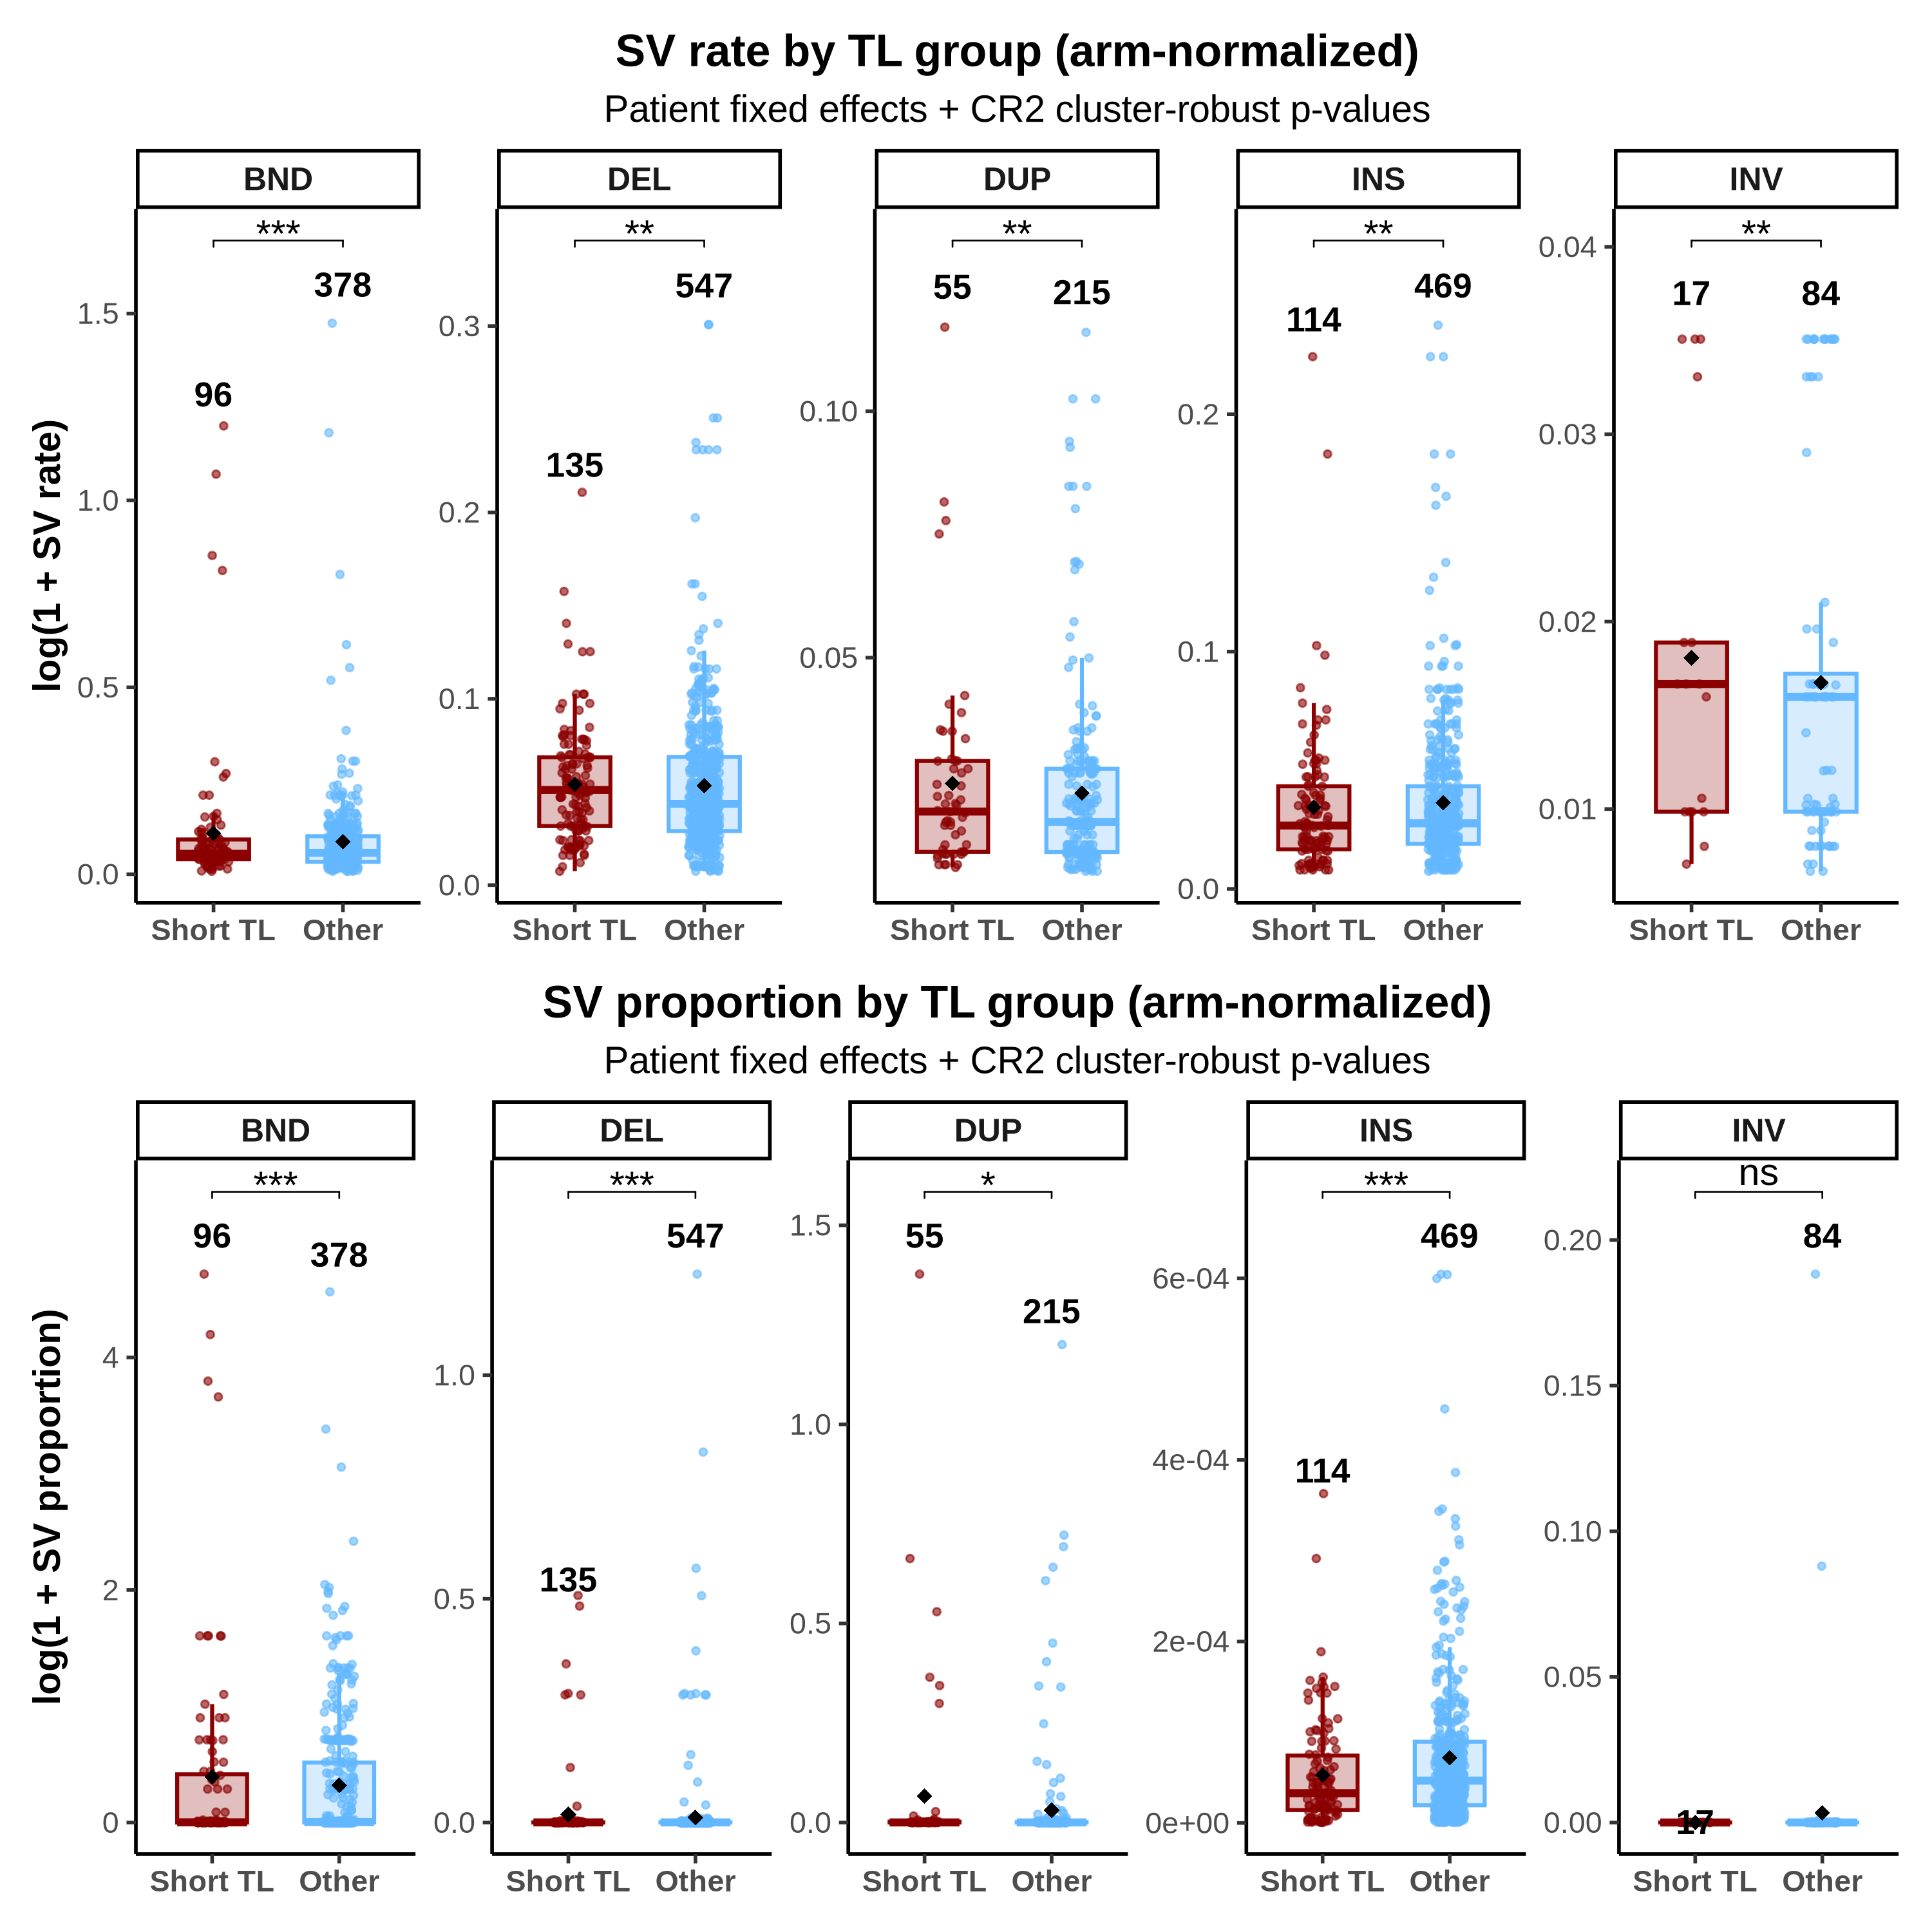

In [33]:
# Load patchwork for combining plots
library(patchwork)

# Set plot size for Jupyter / RMarkdown
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 300)

# Generate arm-normalized SV rate and proportion plots
p_arm_rate <- make_FE_plot_with_counts(
  merged_data, "sv_rate", "SV rate",
  "SV rate by TL group (arm-normalized)"
)

p_arm_prop <- make_FE_plot_with_counts(
  merged_data, "sv_proportion", "SV proportion",
  "SV proportion by TL group (arm-normalized)"
)

# Combine both plots side by side
main_panel <- p_arm_rate + p_arm_prop + patchwork::plot_layout(ncol = 1, widths = c(1,1))

# Print the combined plot
print(main_panel)


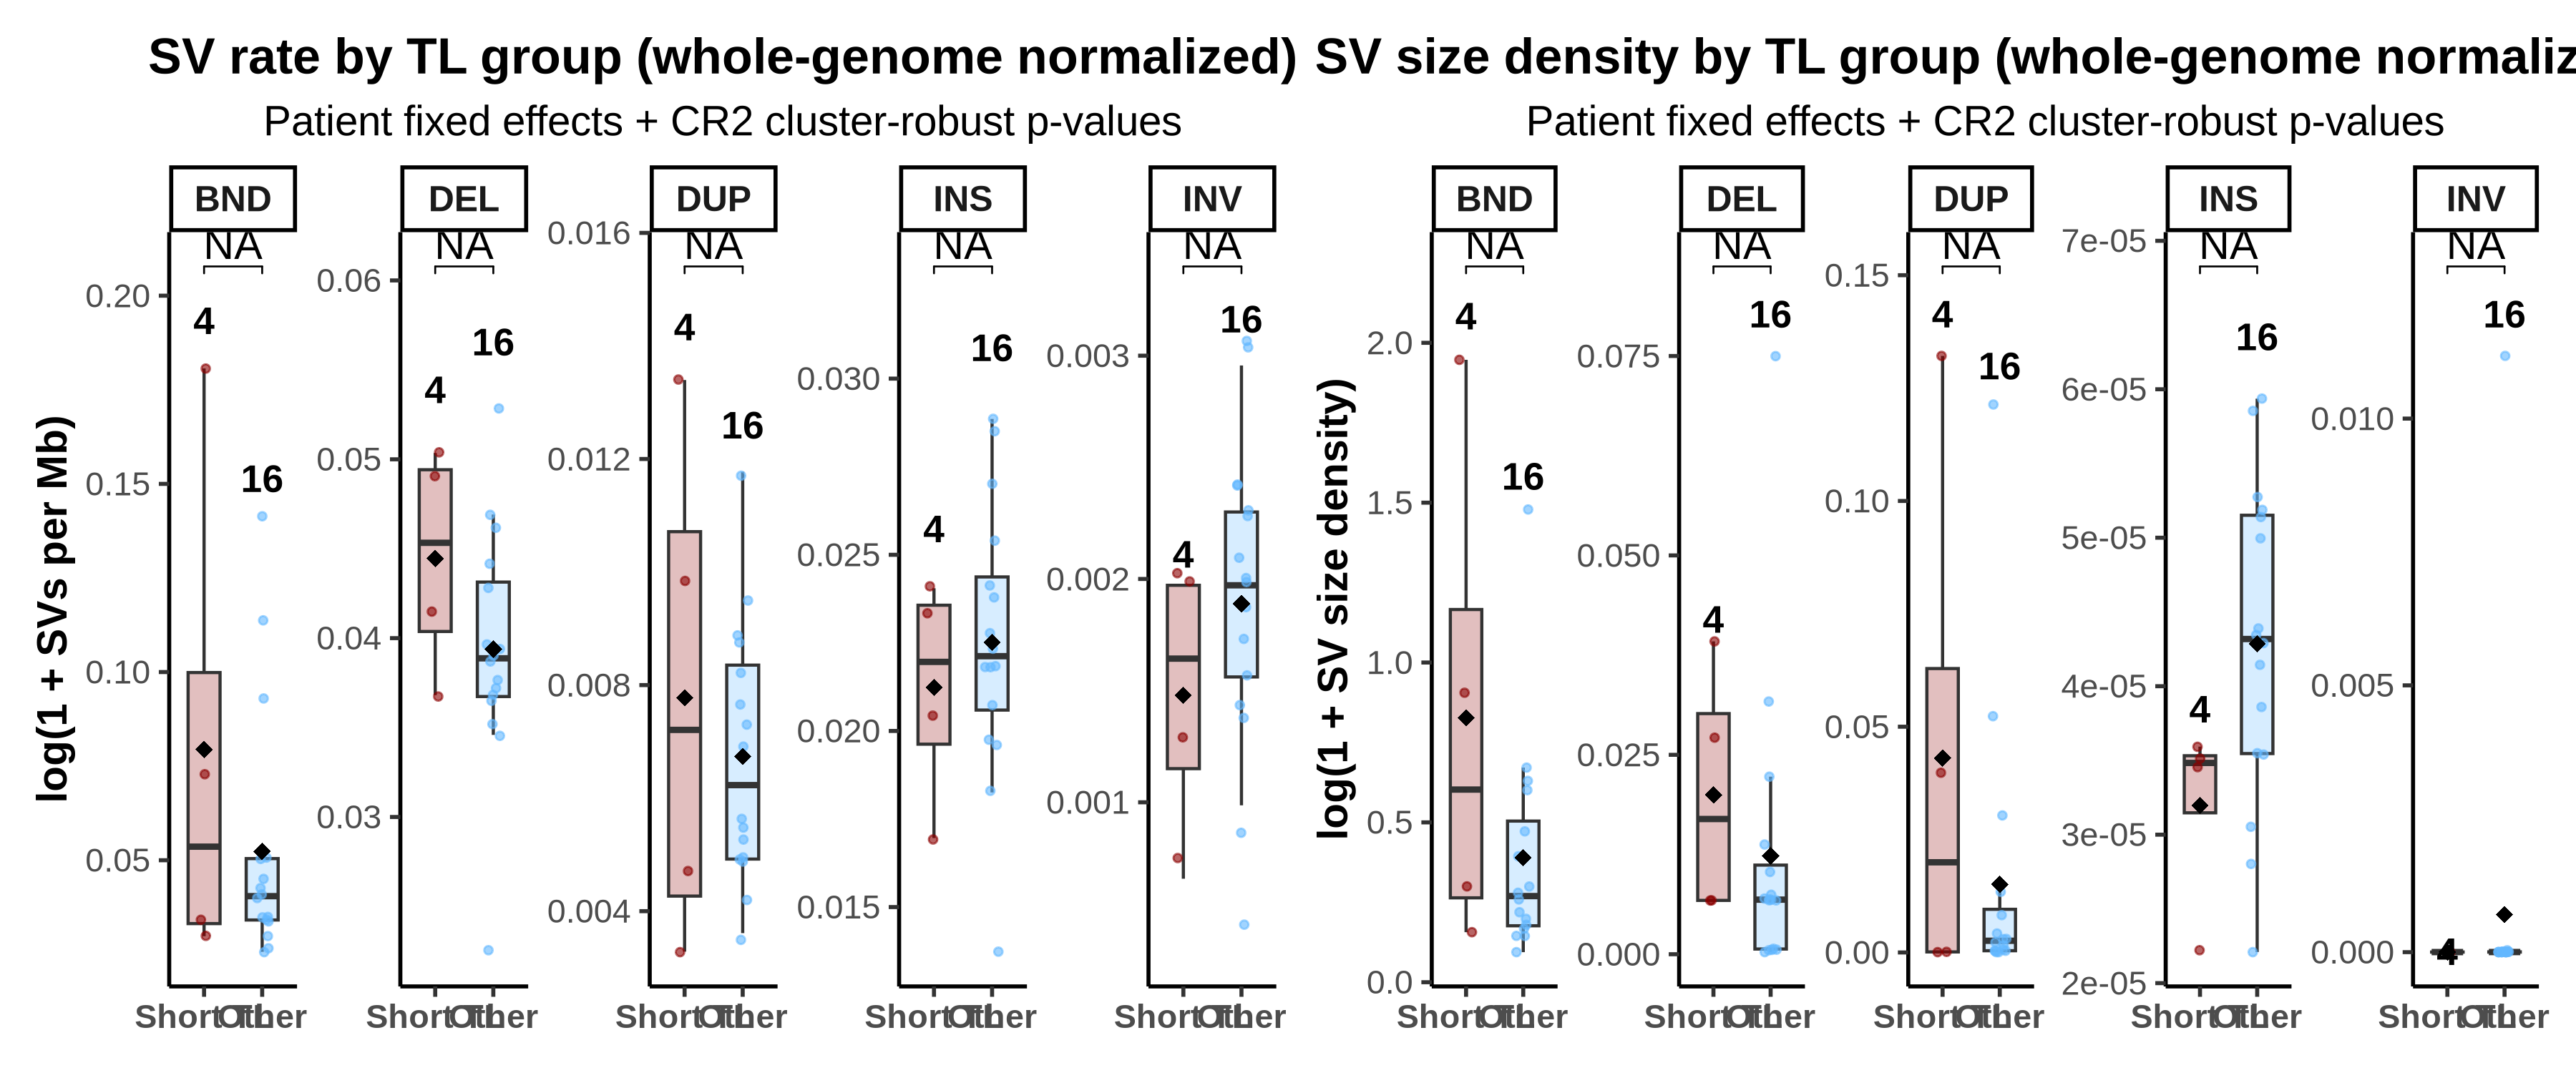

In [38]:
## -------------------------------
## Libraries
## -------------------------------
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(ggpubr)
  library(clubSandwich)
  library(patchwork)
})

## -------------------------------
## Helper: p-value → stars
## -------------------------------
p_to_stars <- function(p) {
  ifelse(is.na(p), "NA",
         ifelse(p < 0.001, "***",
                ifelse(p < 0.01, "**",
                       ifelse(p < 0.05, "*", "ns"))))
}

## -------------------------------
## Whole-genome size (Mb)
## T2T-CHM13 ~3.04 Gb
## -------------------------------
WG_MB <- 3040


## ===============================
## 1) Collapse arm-level data
##    → patient × SV type
## ===============================

wg_data <- merged_data %>%
  group_by(Sample_ID, type, TL_group) %>%
  summarise(
    sv_count_wg = sum(sv_count, na.rm = TRUE),
    sv_size_wg  = sum(sv_size_sum, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    sv_rate_wg = sv_count_wg / WG_MB,
    sv_prop_wg = sv_size_wg  / WG_MB
  )

## sanity check
stopifnot(all(c("Sample_ID","type","TL_group",
                "sv_rate_wg","sv_prop_wg") %in% colnames(wg_data)))


## ===============================
## 2) Plot function (WG-normalized)
## ===============================

make_FE_plot_wg <- function(df, ycol, ylab, title_text) {

  d <- df %>%
    mutate(
      TL_group  = factor(TL_group, levels = c("Short TL", "Other")),
      Sample_ID = factor(Sample_ID),
      type      = factor(type),
      y_raw     = as.numeric(.data[[ycol]]),
      y         = log1p(y_raw)
    ) %>%
    filter(is.finite(y))

  ## ---- CR2 robust p-values per SV type ----
  pvals <- d %>%
    group_by(type) %>%
    filter(n() >= 2) %>%
    group_modify(~ {
      fit <- lm(y ~ TL_group + Sample_ID, data = .x)
      ct  <- clubSandwich::coef_test(
        fit, vcov = "CR2", cluster = .x$Sample_ID
      )
      tibble(p = ct["TL_groupOther", "p_Satt"])
    }) %>%
    ungroup() %>%
    mutate(
      p.signif = p_to_stars(p),
      group1 = "Short TL",
      group2 = "Other"
    )

  ## ---- y-position for stars ----
  ypos <- d %>%
    group_by(type) %>%
    summarise(
      y.position = max(y, na.rm = TRUE) * 1.15,
      .groups = "drop"
    )

  pvals <- left_join(pvals, ypos, by = "type")

  ## ---- counts per TL group ----
  counts <- d %>%
    group_by(type, TL_group) %>%
    summarise(
      n = n(),
      y_max = max(y, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(y_count = y_max * 1.07)

  ## ---- Plot ----
  ggplot() +
    geom_boxplot(
      data = d,
      aes(x = TL_group, y = y, fill = TL_group),
      outlier.shape = NA,
      width = 0.55,
      alpha = 0.25
    ) +
    geom_jitter(
      data = d,
      aes(x = TL_group, y = y, color = TL_group),
      width = 0.12,
      size = 1,
      alpha = 0.6
    ) +
    stat_summary(
      data = d,
      aes(x = TL_group, y = y),
      fun = mean,
      geom = "point",
      shape = 18,
      size = 2.4,
      color = "black"
    ) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",
      y.position = "y.position",
      tip.length = 0.01,
      size = 5
    ) +
    geom_text(
      data = counts,
      aes(x = TL_group, y = y_count, label = n),
      fontface = "bold",
      size = 4.5
    ) +
    scale_fill_manual(
      values = c("Short TL" = "darkred", "Other" = "steelblue1")
    ) +
    scale_color_manual(
      values = c("Short TL" = "darkred", "Other" = "steelblue1")
    ) +
    labs(
      title = title_text,
      subtitle = "Patient fixed effects + CR2 cluster-robust p-values",
      x = NULL,
      y = paste0("log(1 + ", ylab, ")")
    ) +
    theme_classic(base_size = 14) +
    theme(
      strip.text = element_text(face = "bold", size = 12),
      axis.title.y = element_text(face = "bold"),
      axis.text.x  = element_text(face = "bold"),
      plot.title   = element_text(face = "bold", hjust = 0.5),
      plot.subtitle= element_text(hjust = 0.5),
      legend.position = "none"
    )
}


## ===============================
## 3) Generate FINAL figures
## ===============================

options(repr.plot.width = 12,
        repr.plot.height = 5,
        repr.plot.res = 300)

p_wg_rate <- make_FE_plot_wg(
  wg_data,
  "sv_rate_wg",
  "SVs per Mb",
  "SV rate by TL group (whole-genome normalized)"
)

p_wg_prop <- make_FE_plot_wg(
  wg_data,
  "sv_prop_wg",
  "SV size density",
  "SV size density by TL group (whole-genome normalized)"
)

## Main panel
main_panel <- p_wg_rate + p_wg_prop +
  plot_layout(ncol = 2, widths = c(1, 1))

print(main_panel)


## ===============================
## 4) Optional: save for paper
## ===============================
# ggsave(
#   "Fig3_whole_genome_SV_TL.pdf",
#   main_panel,
#   width = 12,
#   height = 5,
#   dpi = 300,
#   useDingbats = FALSE
# )


In [47]:
make_FE_plot_with_counts <- function(df, ycol, ylab, title_text) {

  # ---- SAFETY: normalize TL column name ----
  if (!"TL_group" %in% colnames(df)) {
    stop("TL_group column not found in input data")
  }

  d <- df %>%
    mutate(
      TL_group = factor(.data[["TL_group"]], levels = c("Short TL", "Other")),
      y_raw = as.numeric(.data[[ycol]]),
      y = log1p(y_raw),
      Sample_ID = factor(Sample_ID),
      chr_arm   = factor(chr_arm),
      type      = factor(type)
    ) %>%
    filter(is.finite(y))

  # ---- Mixed-effects model p-values ----
  pvals <- d %>%
    group_by(type) %>%
    filter(n() >= 2) %>%
    group_modify(~ {
      fit <- lmer(y ~ TL_group + (1 | Sample_ID), data = .x)
      pval <- summary(fit)$coefficients["TL_groupOther", "Pr(>|t|)"]
      tibble(p = pval)
    }) %>%
    ungroup() %>%
    mutate(
      p.signif = p_to_stars(p),
      group1 = "Short TL",
      group2 = "Other"
    )

  # ---- y-position for stars ----
  ypos <- d %>%
    group_by(type) %>%
    summarise(y.position = max(y, na.rm = TRUE) * 1.15, .groups = "drop")

  pvals <- left_join(pvals, ypos, by = "type")

  # ---- counts per TL_group ----
  counts <- d %>%
    group_by(type, TL_group) %>%
    summarise(n = n(), y_max = max(y, na.rm = TRUE), .groups = "drop") %>%
    mutate(y_count = y_max * 1.07)

  # ---- plot ----
  ggplot() +
    geom_boxplot(
      data = d,
      aes(x = TL_group, y = y, color = TL_group, fill = TL_group),
      outlier.shape = NA, alpha = 0.25, width = 0.55, linewidth = 0.7
    ) +
    geom_jitter(
      data = d,
      aes(x = TL_group, y = y, color = TL_group),
      width = 0.12, size = 1, alpha = 0.6
    ) +
    stat_summary(
      data = d,
      aes(x = TL_group, y = y),
      fun = mean, geom = "point", shape = 18, size = 2.4, color = "black"
    ) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",
      y.position = "y.position",
      tip.length = 0.01,
      size = 5
    ) +
    geom_text(
      data = counts,
      aes(x = TL_group, y = y_count, label = n),
      size = 4.5, fontface = "bold"
    ) +
    scale_color_manual(values = c("Short TL" = "darkred",
                                  "Other" = "steelblue1")) +
    scale_fill_manual(values = c("Short TL" = "darkred",
                                 "Other" = "steelblue1")) +
    labs(
      title = title_text,
      subtitle = "Patient random intercept (1 | Sample_ID) + mixed model p-values",
      x = NULL,
      y = paste0("log(1 + ", ylab, ")")
    ) +
    theme_classic(base_size = 14) +
    theme(
      axis.title.y = element_text(face = "bold"),
      axis.text.x  = element_text(face = "bold"),
      strip.text   = element_text(face = "bold", size = 12),
      plot.title   = element_text(face = "bold", hjust = 0.5),
      plot.subtitle= element_text(hjust = 0.5),
      legend.position = "none"
    )
}


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



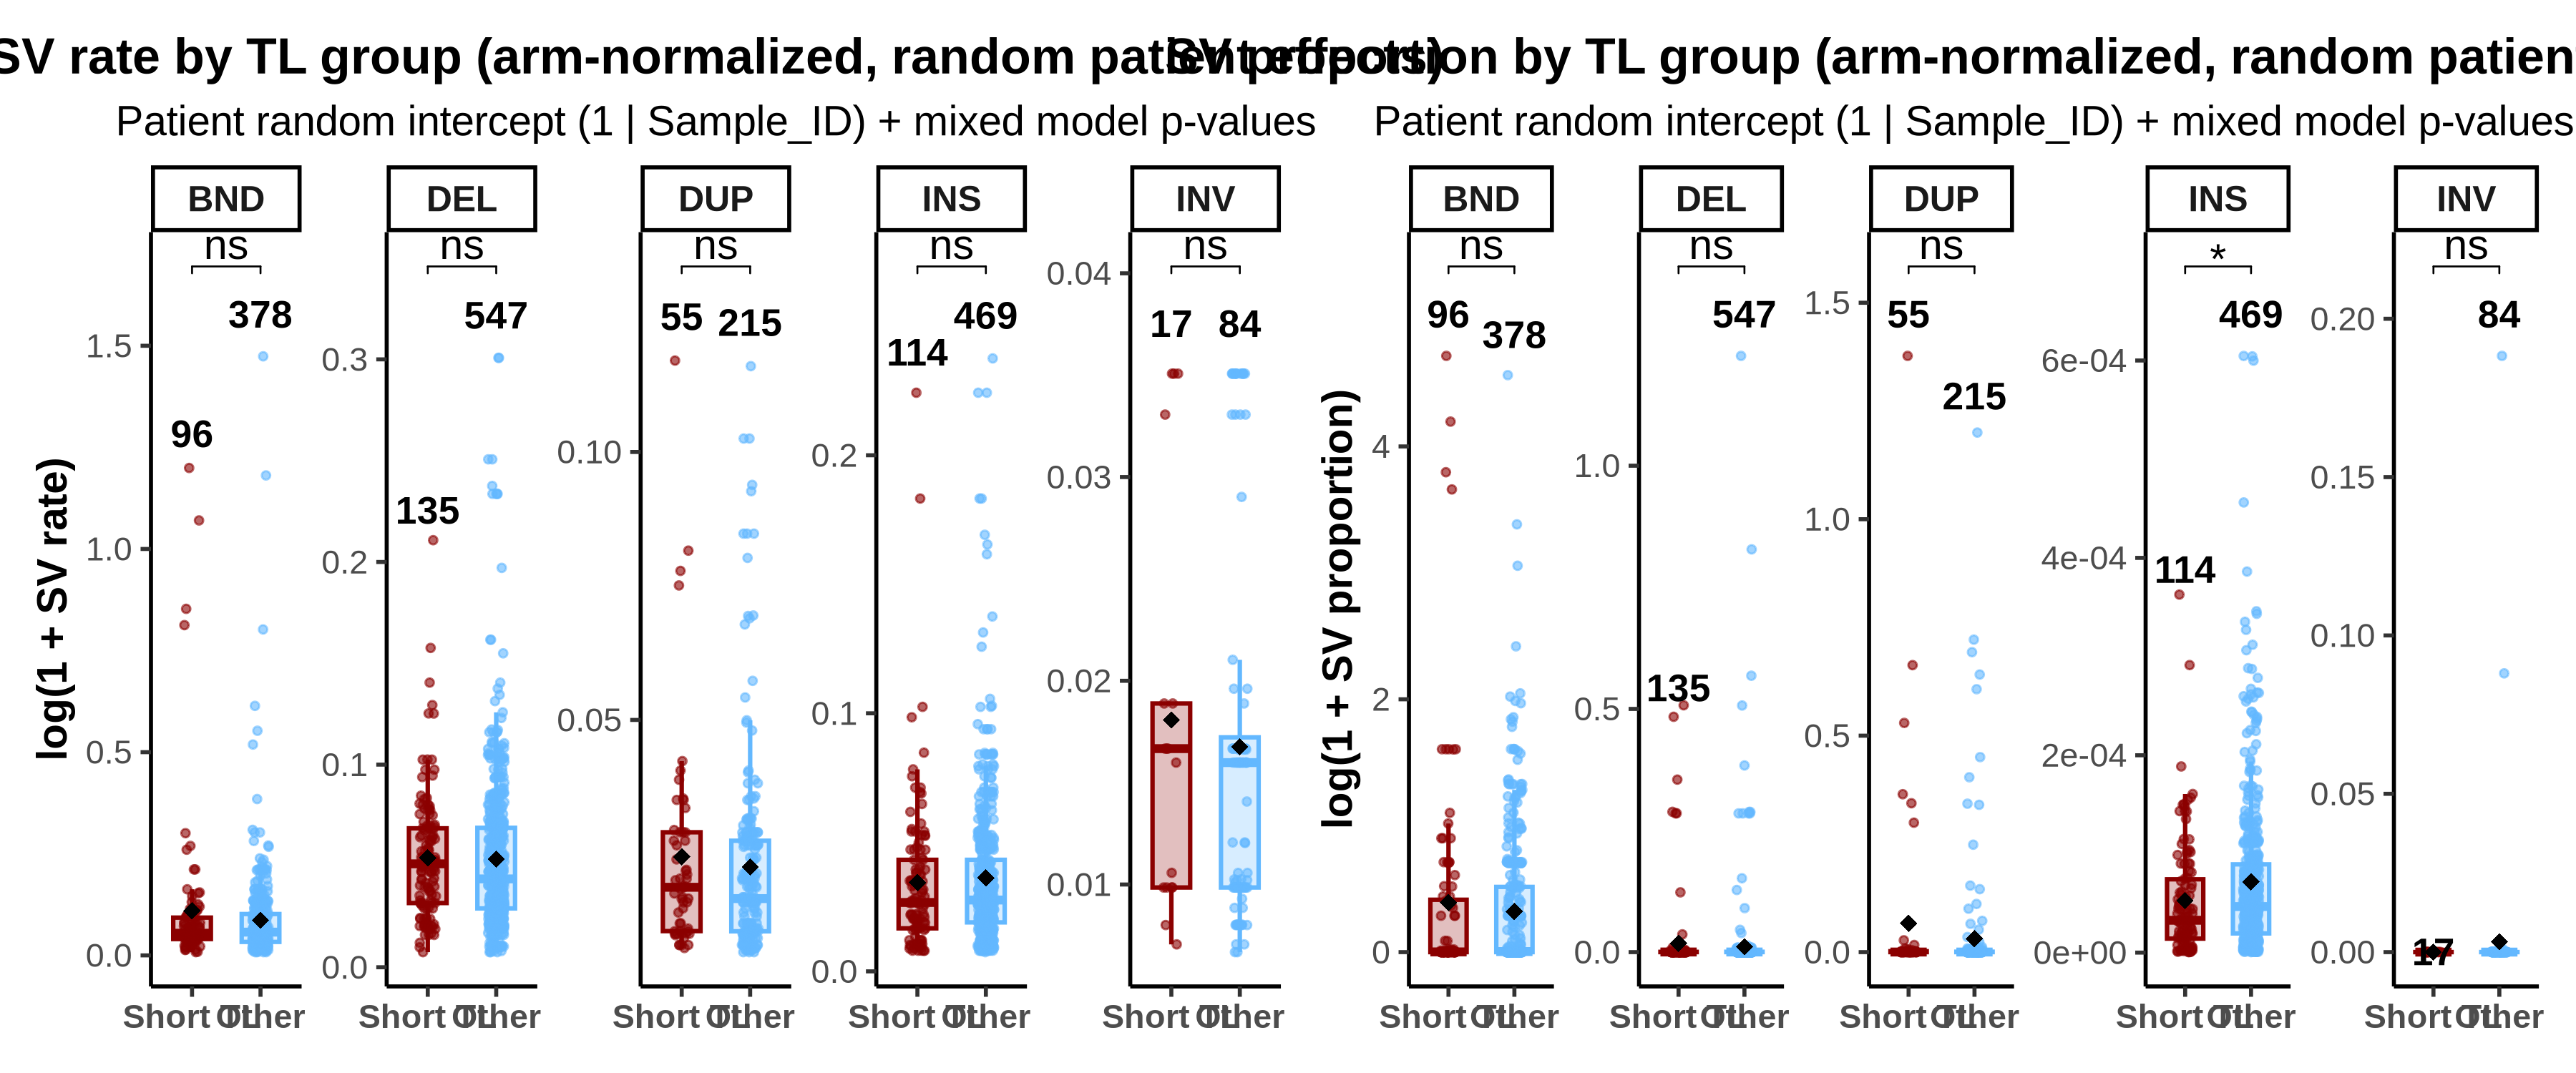

In [48]:
# Example: SV rate per patient
p_sv_rate <- make_FE_plot_with_counts(
  merged_data,
  ycol = "sv_rate",
  ylab = "SV rate",
  title_text = "SV rate by TL group (arm-normalized, random patient effects)"
)

# Example: SV proportion per patient
p_sv_prop <- make_FE_plot_with_counts(
  merged_data,
  ycol = "sv_proportion",
  ylab = "SV proportion",
  title_text = "SV proportion by TL group (arm-normalized, random patient effects)"
)

# Combine both plots side by side
library(patchwork)
main_panel <- p_sv_rate + p_sv_prop + plot_layout(ncol = 2, widths = c(1,1))

# Print the combined plot
print(main_panel)
